Device: cpu

TRAINING HSV MODEL

Training HSV model
Loading CIFAR-10 dataset...


100%|██████████| 170M/170M [04:03<00:00, 700kB/s]  



Training for 5 epochs...
--------------------------------------------------------------------------------

Epoch 1/5 - Training...
  Batch 50/352 - Loss: 1.7487
  Batch 100/352 - Loss: 1.7098
  Batch 150/352 - Loss: 1.7203
  Batch 200/352 - Loss: 1.3991
  Batch 250/352 - Loss: 1.2876
  Batch 300/352 - Loss: 1.3791
  Batch 350/352 - Loss: 1.2439
  Validating...

Epoch 1/5 Summary:
  Train Loss: 1.5619 | Train Acc: 42.61%
  Val Loss:   1.3246 | Val Acc:   51.26%
  Gap: -8.65%

Epoch 2/5 - Training...
  Batch 50/352 - Loss: 1.3417
  Batch 100/352 - Loss: 1.1459
  Batch 150/352 - Loss: 1.1130
  Batch 200/352 - Loss: 1.1139
  Batch 250/352 - Loss: 0.9367
  Batch 300/352 - Loss: 0.9220
  Batch 350/352 - Loss: 0.9697
  Validating...

Epoch 2/5 Summary:
  Train Loss: 1.0791 | Train Acc: 61.48%
  Val Loss:   1.1746 | Val Acc:   62.32%
  Gap: -0.84%

Epoch 3/5 - Training...
  Batch 50/352 - Loss: 1.0725
  Batch 100/352 - Loss: 0.8970
  Batch 150/352 - Loss: 0.8177
  Batch 200/352 - Loss: 0.8798

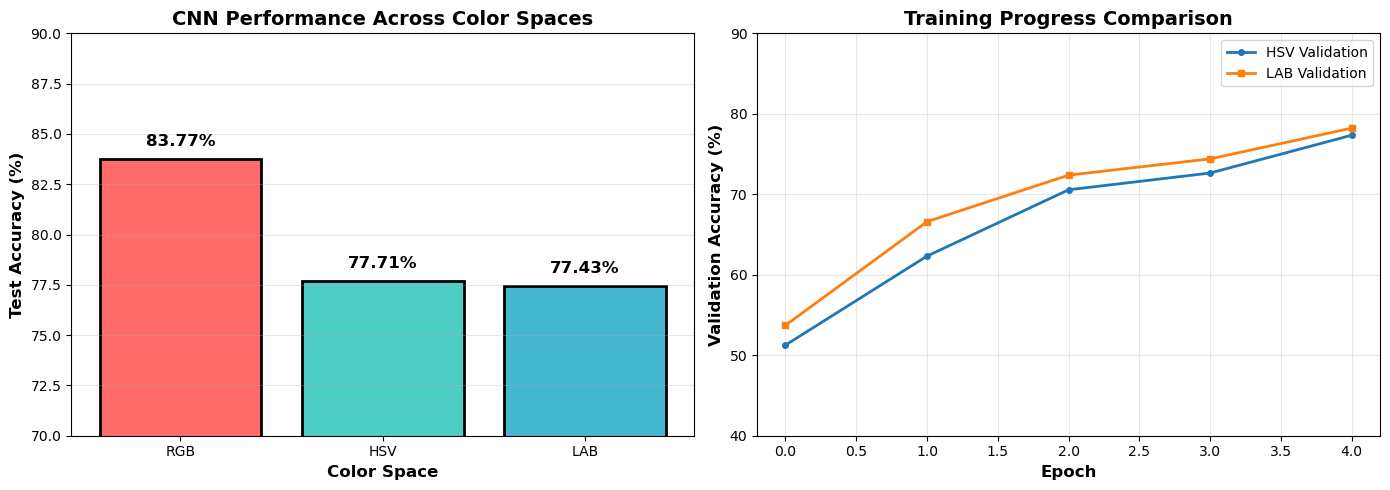


✅ TASK C COMPLETED SUCCESSFULLY!
   - HSV model trained
   - LAB model trained
   - Comparison plot saved to outputs/plots/color_space_comparison_complete.png


In [3]:
"""HSV and LAB Training for Jupyter Notebook"""

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

# ================= CONFIGURATION =================
class Config:
    MAX_EPOCHS = 5
    BATCH_SIZE = 128
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4
    VAL_SPLIT = 0.1
    DATA_DIR = "./data"
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    OUTPUT_DIR = "outputs"
    PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
    LOGS_DIR = os.path.join(OUTPUT_DIR, "logs")
    CHECKPOINTS_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
    
    @classmethod
    def create_dirs(cls):
        for dir_path in [cls.PLOTS_DIR, cls.LOGS_DIR, cls.CHECKPOINTS_DIR]:
            os.makedirs(dir_path, exist_ok=True)

Config.create_dirs()
print(f"Device: {Config.DEVICE}")

# ================= COLOR SPACE TRANSFORMS =================
class ToHSV:
    def __call__(self, img):
        img = np.array(img, dtype=np.float32) / 255.0
        r, g, b = img[..., 0], img[..., 1], img[..., 2]
        
        max_rgb = np.maximum(np.maximum(r, g), b)
        min_rgb = np.minimum(np.minimum(r, g), b)
        diff = max_rgb - min_rgb
        
        h = np.zeros_like(max_rgb)
        mask = diff != 0
        r_mask = (max_rgb == r) & mask
        g_mask = (max_rgb == g) & mask
        b_mask = (max_rgb == b) & mask
        
        h[r_mask] = (60 * ((g[r_mask] - b[r_mask]) / diff[r_mask])) % 360
        h[g_mask] = (60 * ((b[g_mask] - r[g_mask]) / diff[g_mask]) + 120) % 360
        h[b_mask] = (60 * ((r[b_mask] - g[b_mask]) / diff[b_mask]) + 240) % 360
        
        s = np.zeros_like(max_rgb)
        s[max_rgb != 0] = diff[max_rgb != 0] / max_rgb[max_rgb != 0]
        v = max_rgb
        
        hsv = np.stack([h/360.0, s, v], axis=2)
        return transforms.ToTensor()(hsv)

class ToLAB:
    def __call__(self, img):
        img = np.array(img, dtype=np.float32) / 255.0
        r, g, b = img[..., 0], img[..., 1], img[..., 2]
        
        r = np.where(r > 0.04045, ((r + 0.055) / 1.055) ** 2.4, r / 12.92)
        g = np.where(g > 0.04045, ((g + 0.055) / 1.055) ** 2.4, g / 12.92)
        b = np.where(b > 0.04045, ((b + 0.055) / 1.055) ** 2.4, b / 12.92)
        
        x = r * 0.4124564 + g * 0.3575761 + b * 0.1804375
        y = r * 0.2126729 + g * 0.7151522 + b * 0.0721750
        z = r * 0.0193339 + g * 0.1191920 + b * 0.9503041
        
        x, y, z = x / 0.950456, y / 1.0, z / 1.088754
        x = np.where(x > 0.008856, x ** (1/3), (7.787 * x) + 16/116)
        y = np.where(y > 0.008856, y ** (1/3), (7.787 * y) + 16/116)
        z = np.where(z > 0.008856, z ** (1/3), (7.787 * z) + 16/116)
        
        l = (116 * y) - 16
        a = 500 * (x - y)
        b = 200 * (y - z)
        
        lab = np.stack([l/100.0, (a+128)/256.0, (b+128)/256.0], axis=2)
        return transforms.ToTensor()(lab)

# ================= MODEL =================
import torchvision.models as models

class CNNBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

# ================= TRAINING FUNCTION =================
def train_color_space(color_space="hsv"):
    """Train model for specific color space"""
    
    print(f"\n{'='*60}")
    print(f"Training {color_space.upper()} model")
    print(f"{'='*60}")
    
    # Setup transforms based on color space
    if color_space == "hsv":
        transform_train = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            ToHSV(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        transform_val = transforms.Compose([
            ToHSV(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    else:  # lab
        transform_train = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomCrop(32, padding=4),
            ToLAB(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        transform_val = transforms.Compose([
            ToLAB(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    
    # Load data
    print("Loading CIFAR-10 dataset...")
    train_dataset = torchvision.datasets.CIFAR10(
        root=Config.DATA_DIR, train=True, download=True, transform=transform_train
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root=Config.DATA_DIR, train=False, download=True, transform=transform_val
    )
    
    # Split train/val
    val_size = int(len(train_dataset) * Config.VAL_SPLIT)
    train_size = len(train_dataset) - val_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    # Create data loaders
    train_loader = DataLoader(train_subset, batch_size=Config.BATCH_SIZE, 
                             shuffle=True, num_workers=0)
    val_loader = DataLoader(val_subset, batch_size=Config.BATCH_SIZE, 
                           shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, 
                            shuffle=False, num_workers=0)
    
    # Model
    model = CNNBaseline().to(Config.DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE, 
                          weight_decay=Config.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3)
    
    # Training tracking
    best_val_acc = 0
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    print(f"\nTraining for {Config.MAX_EPOCHS} epochs...")
    print("-" * 80)
    
    start_time = time.time()
    
    for epoch in range(Config.MAX_EPOCHS):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        print(f"\nEpoch {epoch+1}/{Config.MAX_EPOCHS} - Training...")
        
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
            
            # Progress indicator
            if (batch_idx + 1) % 50 == 0:
                print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        print(f"  Validating...")
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        scheduler.step(avg_val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 
                      os.path.join(Config.CHECKPOINTS_DIR, f"best_{color_space}.pt"))
        
        # Print epoch results
        gap = train_acc - val_acc
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{Config.MAX_EPOCHS} Summary:")
        print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Gap: {gap:.2f}%")
        print(f"{'='*60}")
    
    training_time = time.time() - start_time
    
    # Load best model and test
    best_model_path = os.path.join(Config.CHECKPOINTS_DIR, f"best_{color_space}.pt")
    model.load_state_dict(torch.load(best_model_path))
    
    model.eval()
    test_correct = 0
    test_total = 0
    print(f"\nTesting on {len(test_loader)} batches...")
    with torch.no_grad():
        for batch_idx, (inputs, labels) in enumerate(test_loader):
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()
            
            if (batch_idx + 1) % 20 == 0:
                print(f"  Test batch {batch_idx+1}/{len(test_loader)}")
    
    test_acc = 100. * test_correct / test_total
    
    print(f"\n{'='*60}")
    print(f"{color_space.upper()} TRAINING COMPLETE!")
    print(f"{'='*60}")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
    print(f"Final Test Accuracy: {test_acc:.2f}%")
    print(f"Training Time: {training_time/60:.1f} minutes")
    print(f"Model saved to: {best_model_path}")
    
    return {
        "color_space": color_space,
        "best_val_acc": best_val_acc,
        "test_acc": test_acc,
        "training_time": training_time,
        "train_accs": train_accs,
        "val_accs": val_accs
    }

# ================= RUN TRAINING =================
print("\n" + "="*70)
print("TRAINING HSV MODEL")
print("="*70)

# Train HSV
hsv_results = train_color_space("hsv")

print("\n" + "="*70)
print("TRAINING LAB MODEL")  
print("="*70)

# Train LAB
lab_results = train_color_space("lab")

# ================= COMPARE RESULTS =================
print("\n" + "="*70)
print("FINAL COMPARISON - TASK C COMPLETE")
print("="*70)

# Load RGB results if available
rgb_test_acc = 83.77  # Your RGB result from earlier

print(f"\n{'Color Space':<12} {'Test Accuracy':<20}")
print("-" * 35)
print(f"{'RGB':<12} {rgb_test_acc:>6.2f}%")
print(f"{'HSV':<12} {hsv_results['test_acc']:>6.2f}%")
print(f"{'LAB':<12} {lab_results['test_acc']:>6.2f}%")

# Determine best
accuracies = {'RGB': rgb_test_acc, 'HSV': hsv_results['test_acc'], 'LAB': lab_results['test_acc']}
best = max(accuracies, key=accuracies.get)
print(f"\n🏆 Best performing color space: {best} ({accuracies[best]:.2f}%)")

# Create comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart
spaces = list(accuracies.keys())
values = list(accuracies.values())
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(spaces, values, color=colors, edgecolor='black', linewidth=2)

for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_xlabel('Color Space', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('CNN Performance Across Color Spaces', fontsize=14, fontweight='bold')
ax1.set_ylim(70, 90)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Training curves
ax2.plot(hsv_results['val_accs'], label='HSV Validation', linewidth=2, marker='o', markersize=4)
ax2.plot(lab_results['val_accs'], label='LAB Validation', linewidth=2, marker='s', markersize=4)

# Add RGB if you have the data
if 'val_accs' in locals():
    pass  # RGB validation data would go here

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training Progress Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(40, 90)

plt.tight_layout()
plt.savefig('outputs/plots/color_space_comparison_complete.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ TASK C COMPLETED SUCCESSFULLY!")
print("   - HSV model trained")
print("   - LAB model trained")  
print("   - Comparison plot saved to outputs/plots/color_space_comparison_complete.png")

##Vizualization of Plots-Time and Acc Comparison

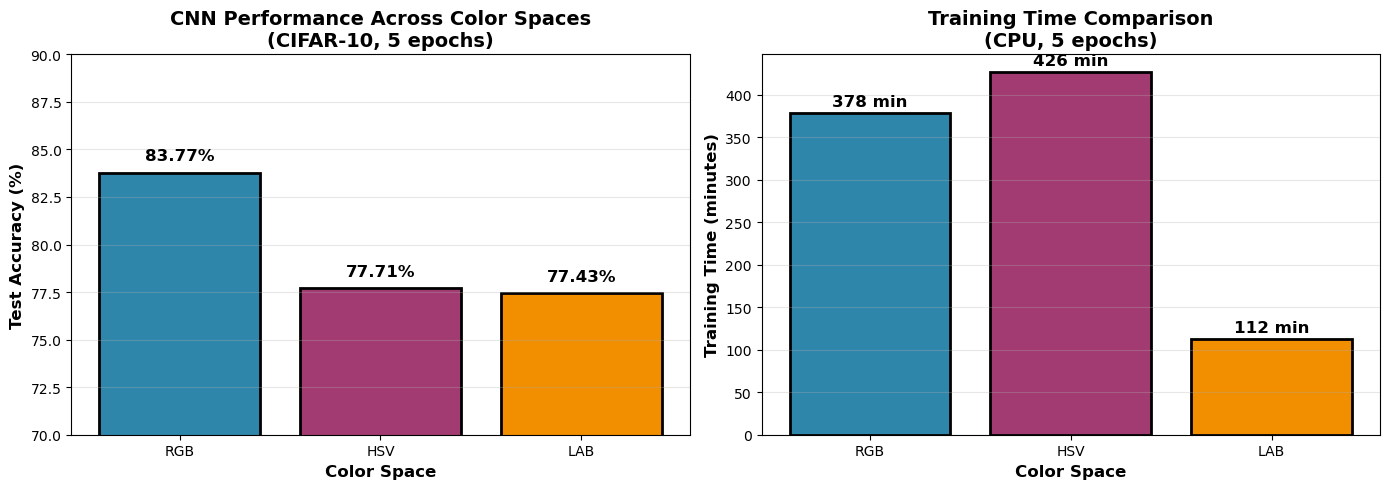

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Results data
color_spaces = ['RGB', 'HSV', 'LAB']
accuracies = [83.77, 77.71, 77.43]
training_times = [378, 426, 112]  # minutes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy Comparison
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax1.bar(color_spaces, accuracies, color=colors, edgecolor='black', linewidth=2)

for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.set_xlabel('Color Space', fontsize=12, fontweight='bold')
ax1.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('CNN Performance Across Color Spaces\n(CIFAR-10, 5 epochs)', fontsize=14, fontweight='bold')
ax1.set_ylim(70, 90)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Training Time Comparison
bars2 = ax2.bar(color_spaces, training_times, color=colors, edgecolor='black', linewidth=2)

for bar, time in zip(bars2, training_times):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{time:.0f} min', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_xlabel('Color Space', fontsize=12, fontweight='bold')
ax2.set_ylabel('Training Time (minutes)', fontsize=12, fontweight='bold')
ax2.set_title('Training Time Comparison\n(CPU, 5 epochs)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('outputs/plots/task_c_complete_analysis.png', dpi=150, bbox_inches='tight')
plt.show()